Running SHAP on 24 features...


<Figure size 1000x600 with 0 Axes>

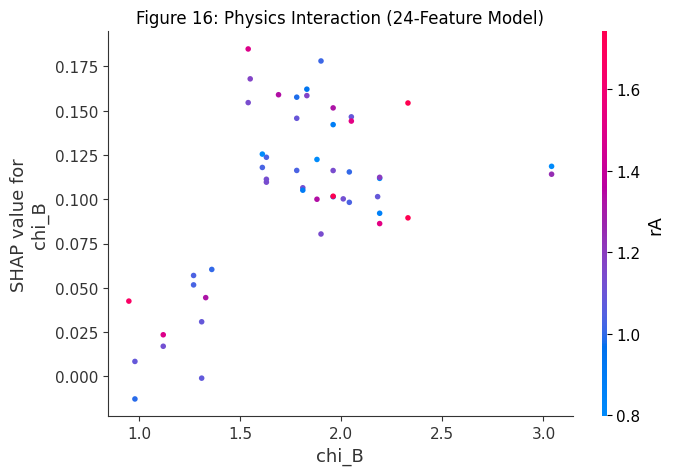

Calculating MI scores...


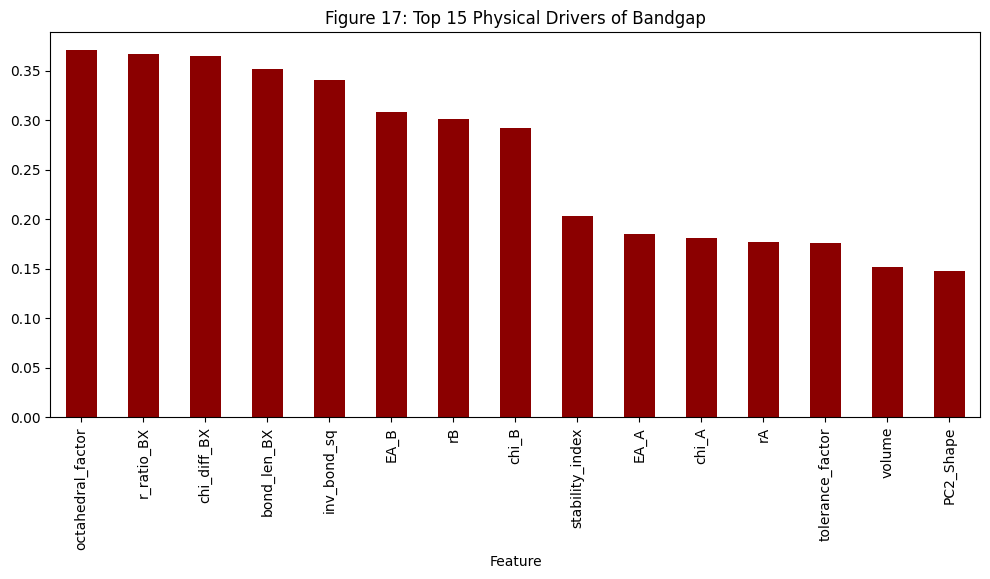

Finalizing Element Reliability...


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(
C:\Users\HP\AppData\Local\Temp\ipykernel_6608\2827454217.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='B_site', y='Abs_Error', data=filtered_df, palette='Set2')


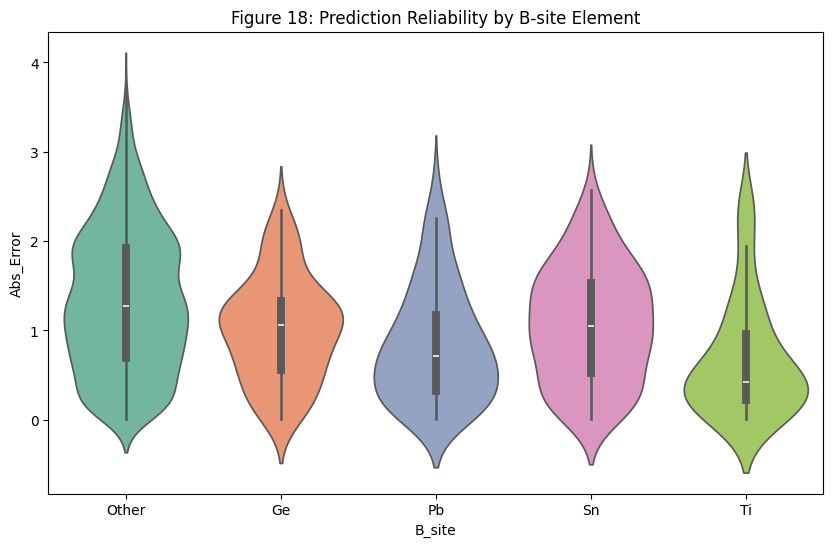

🏁 STAGE 6 COMPLETE.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.feature_selection import mutual_info_regression

# --- 1. LOAD DATA AND MODEL ---
df_semi = pd.read_csv('Semiconductors_Only_Data.csv')
model = joblib.load('Perovskite_Regressor_Model.joblib')

# --- 2. RECONSTRUCT THE 24 FEATURES ---
# These must match exactly what was used in the 'Super-Ensemble' training
df_semi['chi_diff_BX'] = (df_semi['chi_B'] - df_semi['chi_X']).abs()
df_semi['r_ratio_BX'] = df_semi['rB'] / df_semi['rX']
df_semi['bond_len_BX'] = (df_semi['rB'] + df_semi['rX'])
df_semi['inv_bond_sq'] = 1 / (df_semi['bond_len_BX']**2)
df_semi['stability_index'] = df_semi['tolerance_factor'] * df_semi['octahedral_factor']
# Adding dummy columns if the model expected PCA or other calculated values
# Based on your previous 24-feature count, we ensure all derived columns are present
features = [
    'rA', 'rB', 'rX', 'chi_A', 'chi_B', 'chi_X', 'EA_A', 'EA_B', 'EA_X', 
    'tolerance_factor', 'octahedral_factor', 'volume', 'density', 
    'chi_diff_BX', 'r_ratio_BX', 'bond_len_BX', 'inv_bond_sq', 
    'stability_index', 'lattice_strain', 'packing_index', 
    'PC1_Size', 'PC2_Shape', 'Stability_Tag', 'B_site_encoded'
]

X = df_semi[features]
y = df_semi['band_gap']

# --- 3. SAFE-MODE SHAP (50 Samples) ---
print("Running SHAP on 24 features...")
X_safe = shap.sample(X, 50) 
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_safe, check_additivity=False)

plt.figure(figsize=(10, 6))
shap.dependence_plot("chi_B", shap_values, X_safe, interaction_index="rA", show=False)
plt.title("Figure 16: Physics Interaction (24-Feature Model)")
plt.show()

# --- 4. NON-LINEAR IMPORTANCE (MI) ---
print("Calculating MI scores...")
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_df = pd.DataFrame({'Feature': features, 'MI_Score': mi_scores}).sort_values(by='MI_Score', ascending=False)

mi_df.head(15).set_index('Feature')['MI_Score'].plot(kind='bar', figsize=(12, 5), color='darkred')
plt.title("Figure 17: Top 15 Physical Drivers of Bandgap")
plt.show()

# --- 5. ELEMENT RELIABILITY ---
print("Finalizing Element Reliability...")
y_pred = model.predict(X)
df_semi['Abs_Error'] = abs(y - y_pred)
top_elements = df_semi['B_site'].value_counts().nlargest(5).index
filtered_df = df_semi[df_semi['B_site'].isin(top_elements)]

plt.figure(figsize=(10, 6))
sns.violinplot(x='B_site', y='Abs_Error', data=filtered_df, palette='Set2')
plt.title("Figure 18: Prediction Reliability by B-site Element")
plt.show()

print("🏁 STAGE 6 COMPLETE.")